In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from itertools import product
import torchvision
from matplotlib import colors
import matplotlib.patches as patches
from sklearn.cluster import KMeans

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../sympdee/sympde/viz'))
sys.path.append(os.path.join(os.getcwd(), '..'))

from symlie.model.networks.linear import CalculatedP, LinearP
from sympdee.sympde.viz.general_plots import imshows, plot_vals, simple_imshow, savefig, simple_imshow
from symlie.misc.utils_results import get_and_check_Ps, plot_seeds_and_Ps
from symlie.data.transforms import TransformRefactored as Transform

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.misc.viz import wb_plot_pred
from symlie.run import parse_options, main, process_args
from symlie.misc.viz import wb_plot_pred

from symlie.data.transforms import TransformRefactored

from emlp.reps import V, vis
from emlp.groups import Z, O
from emlp.datasets import O5Synthetic
from emlp.nn import gated,gate_indices,uniform_rep
from symlie.misc.viz import wb_plot_pred


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


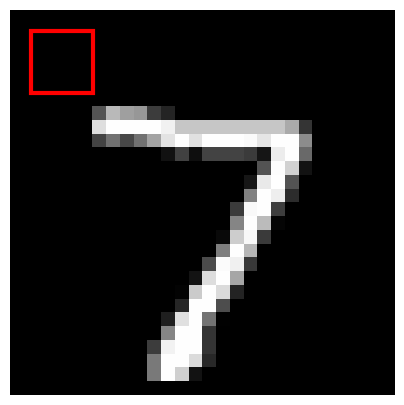

In [2]:
dataset_mnist = torchvision.datasets.MNIST(root='.,/data', train=False, download=False)
img, label = dataset_mnist[0]
img = np.array(img)

fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(img, cmap='gray')
ax.set_axis_off()


# Draw a red square on the top left corner
l = 4.5
rect = patches.Rectangle((1, 1), l, l, linewidth=3, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

savefig(fig, 'mnist_noise_example', '4-method', bbox_inches = 'tight')

In [9]:
args = parse_options(notebook=True)

args.config = 'sine1d'
args.forward_type = 'sine1d'
args.seed = 4

# args.config = 'o5synth'
# args.forward_type = 'o5synth'

net_name = 'analytic'
args.net = 'CombiTrain'
args.implicit_layer_dims = [2, 2]

args.bias = True

args.do_return = True
args.logger = None

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 4


Overwriting max_epochs = 100 to 500
implicit_layer_dims <class 'list'> [2, 2]
implicit_layer_dims <class 'list'> [[56, 56], [8, 8]]
Init rng
Running without logging


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


In [10]:
def kmeans(x: torch.Tensor, n_clusters: int):

    kmeans = KMeans(n_clusters = n_clusters, n_init = 'auto')

    x_array = x.view(-1, 1).numpy()
    x_array_pred = kmeans.fit_predict(x_array)
    x_pred = torch.tensor(x_array_pred).view(x.shape)
    return x_pred.float()

In [11]:
n_cluster_dict = {
    'sine1d'  : [[7, 1], [1, 1]],
    'o5synth' : [[8, 2], [2, 1]],
}

In [12]:
# net = model.net.network
# for layer_idx in [0, 1]:
#     lin = net[layer_idx].linear
#     w, b = lin.proj_w(lin.weight), lin.proj_b(lin.bias)

#     wb_plot_pred(w, b)


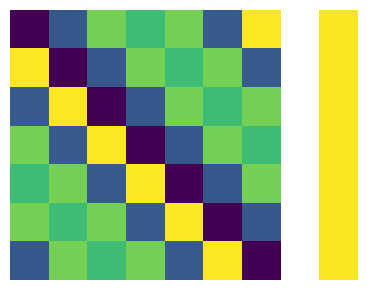

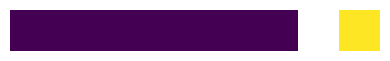

In [13]:
for layer_idx in [0, 1]:
    w, b = model.net.implicit_layers[layer_idx](
        w = model.net.vanilla_layers[layer_idx].weight.data.clone(), 
        b = model.net.vanilla_layers[layer_idx].bias.data.clone() if args.bias else None
    )

    fig = wb_plot_pred(w, b, colorbar = False, set_axis_off=True)

    # n_clusters_w, n_clusters_b = n_cluster_dict[args.forward_type][layer_idx]
    # w_pred, b_pred = kmeans(w, n_clusters_w), kmeans(b, n_clusters_b)
    # b_pred += w_pred.max() + 1
    # fig = wb_plot_pred(
    #     w_pred, b_pred, colorbar=False, set_axis_off=True, cmap='tab10', 
    #     # title = f'Layer {layer_idx + 1} - KMeans'
    # )

    savefig(fig, f'{net_name}_{args.forward_type}_{layer_idx}', '5-experiments', bbox_inches = 'tight')

In [39]:
args = parse_options(notebook=True)

args.config = 'sine1d'
args.forward_type = 'sine1d'
args.seed = 4

# args.config = 'o5synth'
# args.forward_type = 'o5synth'
# args.seed = 7
# # args.seed = 9

net_name = 'emlp'
args.net = 'EMLP'


args.bias = True

args.do_return = True
args.logger = None

process_args(args)

# Training
model, trainer, datamodule = main(args)
net = model.net.network
repin, repout = model.net.rep_in, model.net.rep_out
repin, repout

Seed set to 4


Overwriting max_epochs = 100 to 500
Initing EMLP (PyTorch)
print V V⁰
ch=[7] isinstance(ch,int)=False isinstance(ch,Rep)=False
isinstance(c, Rep): 7 False
Init rng
Running without logging


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


(V, V⁰)

torch.Size([7, 7]) torch.Size([7])
V 7V⁰
torch.Size([7, 7]) torch.Size([7])


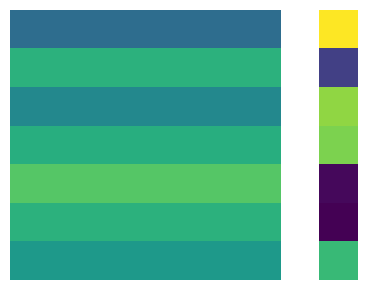

torch.Size([1, 7]) torch.Size([1])


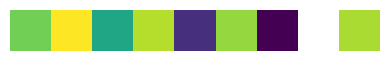

(torch.Size([1, 7]), torch.Size([1]))

In [40]:
for layer_idx in np.arange(len(net)):
    if layer_idx == len(net)-1:
        w, b = net[layer_idx].weight, net[layer_idx].bias
    else:
        lin = net[layer_idx].linear
        w, b = lin.proj_w(lin.weight), lin.proj_b(lin.bias)
        print(lin.weight.shape, lin.bias.shape)
        print(lin.repin_l, lin.repout_l)

    print(w.shape, b.shape)

    fig = wb_plot_pred(w, b, colorbar = False, set_axis_off=True)
    # break

    # savefig(fig, f'{net_name}_{args.forward_type}_{layer_idx}', '5-experiments', bbox_inches = 'tight')

n = 10
w = w[:n, :n].detach()
b = b[:n].detach()

w.shape, b.shape

In [64]:
x = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0]).float()
torch.nn.functional.linear(x, w)

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.2425, -0.3889, -0.5353,
        -0.6816, -0.6356])

In [65]:
x = torch.tensor([6, 7, 8, 9, 0, 0, 0, 0, 0, 0]).float()
torch.nn.functional.linear(x, w)

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.7628, -0.8899, -1.0170,
        -1.1441,  0.0000])

In [66]:
x = torch.tensor([0, 0, 0, 0, 0, 6, 7, 8, 9, 0]).float()
torch.nn.functional.linear(x, w)

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.1154, -0.1346, -0.1539,
        -0.1731,  0.0000])

In [6]:
# layer_idx = 0
# vis(net[layer_idx].linear.repin_l, net[layer_idx].linear.repout_l)

o5synth


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([[0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 2],
       [3, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 3, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 3, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 3, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 3, 0, 0, 0, 0, 1]], dtype=int32)

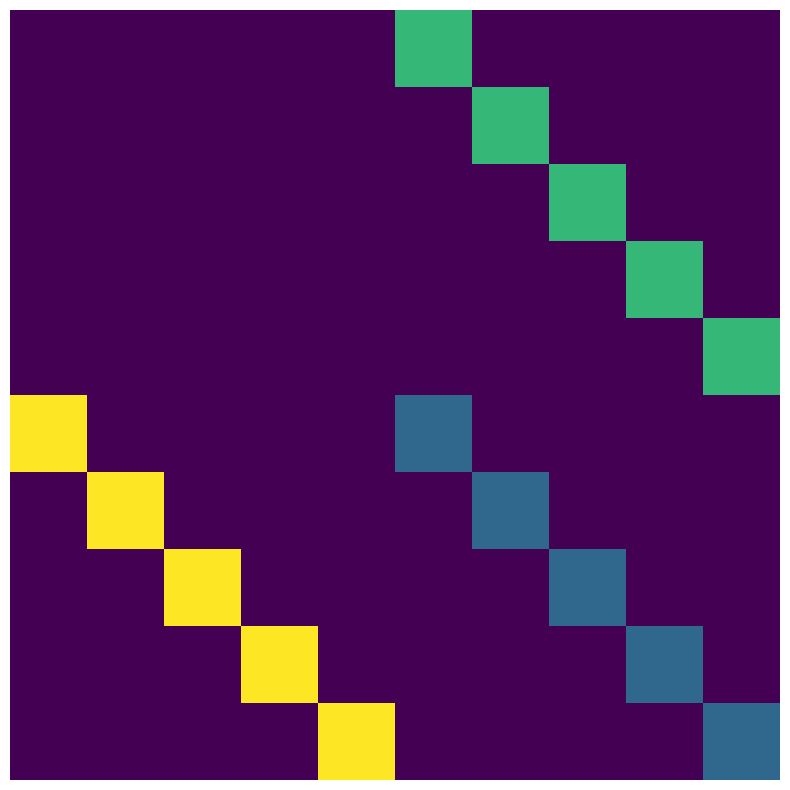

In [22]:
if args.forward_type == 'sine1d':
    print('sine1d')
    group = Z(7)
    repin, repout =  V(group), V**0
elif args.forward_type == 'o5synth':
    print('o5synth')
    set = O5Synthetic(N = 1)
    group, repin, repout = O(5), set.rep_in, set.rep_out
    repin, repout = repin(group), repout(group)
else:
    raise ValueError(f'Unknown forward type: {args.forward_type}')
vis_array = vis(repin, repin)
vis_array

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: 

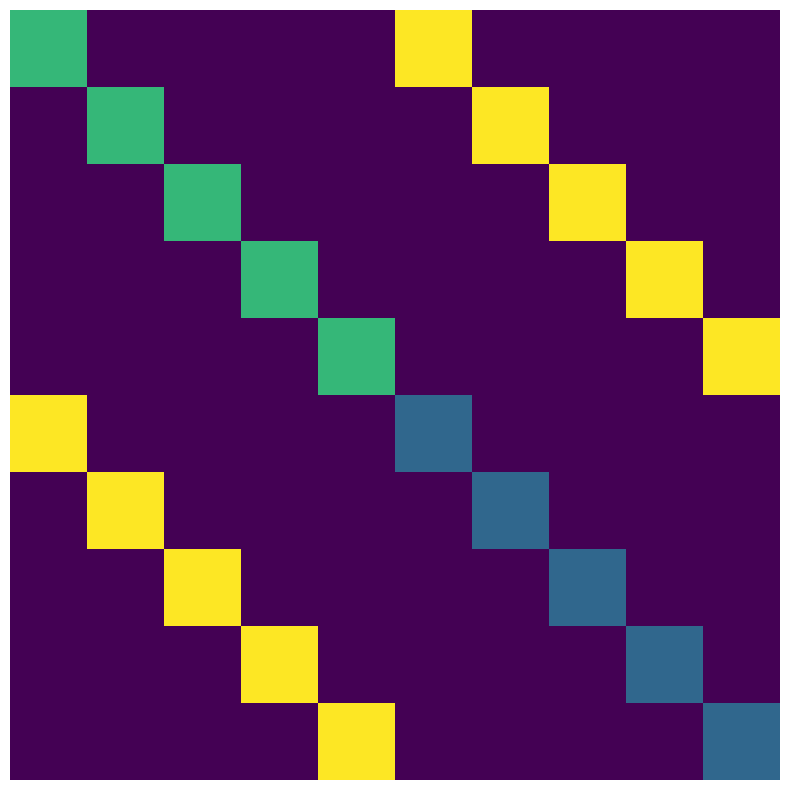

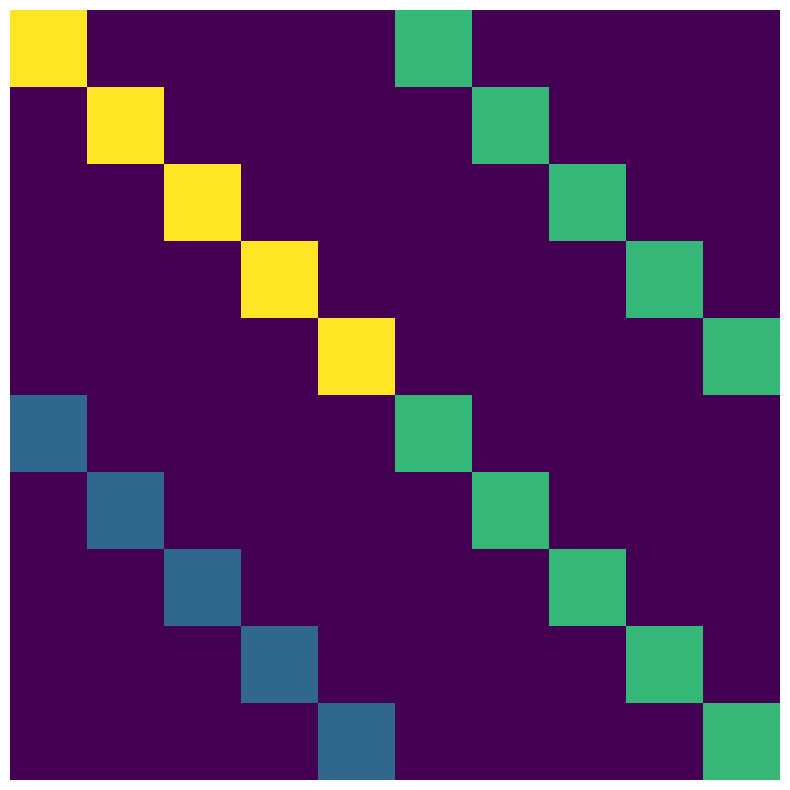

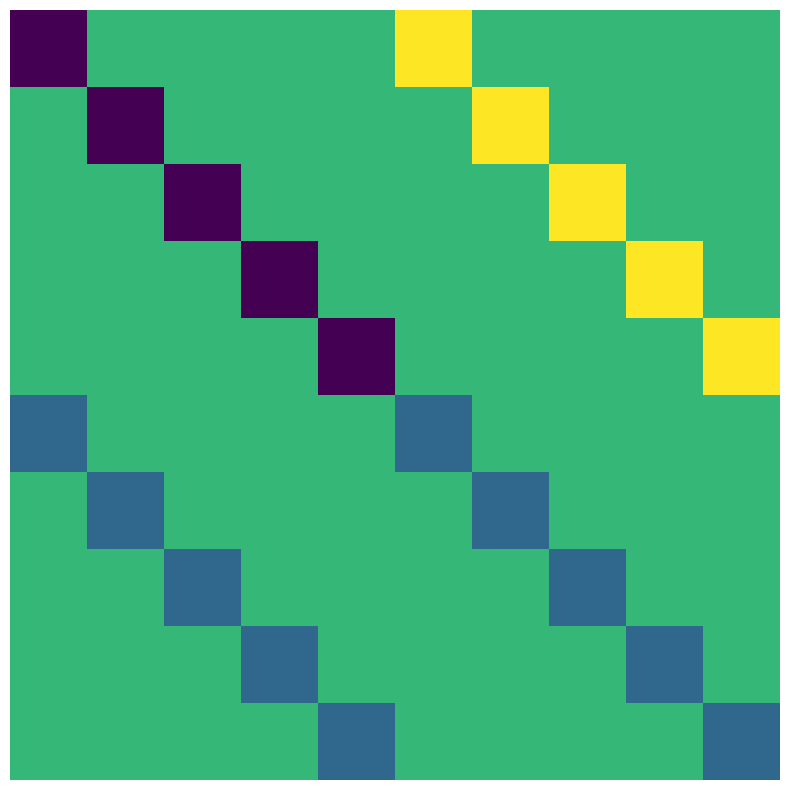

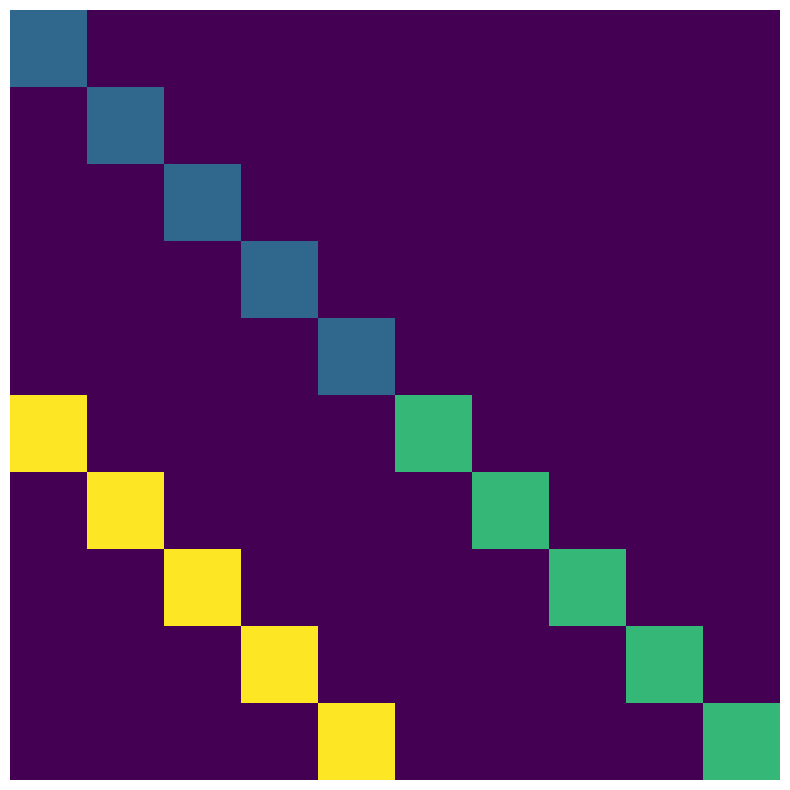

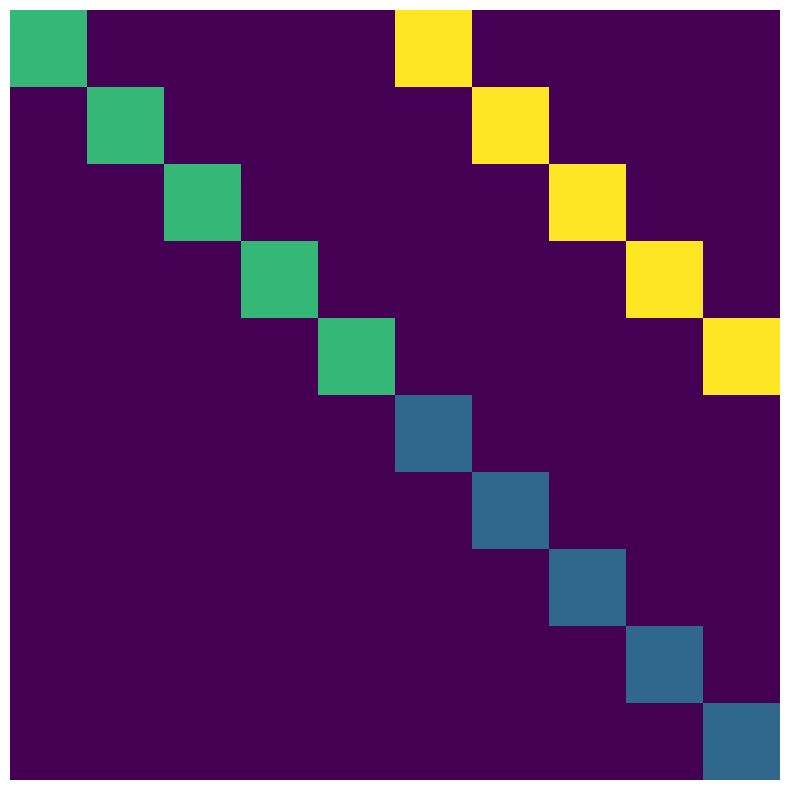

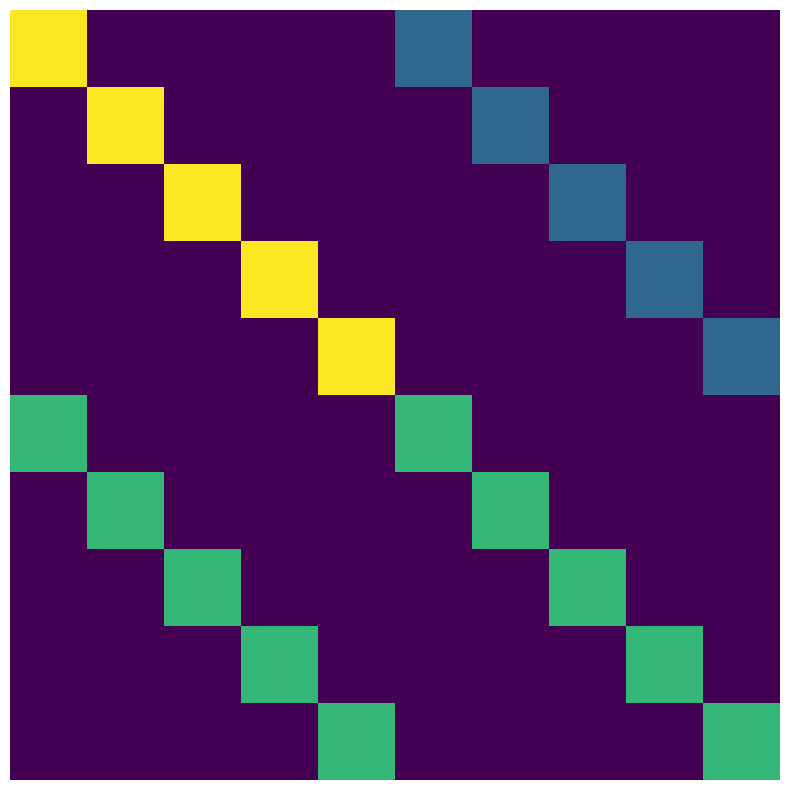

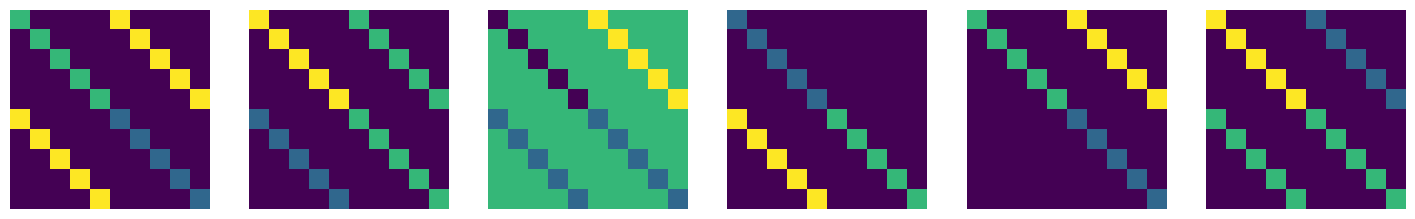

In [28]:
n_vis_arrays = 6
vis_arrays = [vis(repin, repin) for _ in range(n_vis_arrays)]

fig, axs = plt.subplots(1, n_vis_arrays, figsize=(n_vis_arrays * 3, 3))

for i, ax in enumerate(axs):
    ax.imshow(vis_arrays[i])
    ax.set_axis_off()
plt.show()

savefig(fig, f'{args.forward_type}_rep_vis_multiple', '5-experiments', bbox_inches = 'tight')


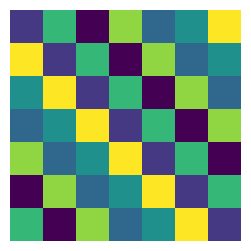

In [356]:
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(vis_array)
ax.set_axis_off()
plt.show()

savefig(fig, f'rep_vis_{args.forward_type}', '5-experiments', bbox_inches = 'tight')

## Old stuff

In [276]:
assert False

AssertionError: 

In [61]:
args = parse_options(notebook=True)
args.config = 'emlp_sine1d'

args.bias = True
args.lossweight_o = 0.

# args.implicit_layer_dims = [2, 2]

args.vanilla_layer_dims =  [7, 7, 7, 7, 1]

args.do_return = True
args.logger = None

process_args(args)

# Training
model, trainer, datamodule = main(args)



Seed set to 1


Overwriting max_epochs = 100 to 500
Initing EMLP (PyTorch)
ch=[7, 7, 7] isinstance(ch,int)=False isinstance(ch,Rep)=False
isinstance(c, Rep): 7 False
isinstance(c, Rep): 7 False
isinstance(c, Rep): 7 False
Init rng
Running without logging


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


(V, V⁰)

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([[4, 6, 0, 2, 3, 5, 1],
       [1, 4, 6, 0, 2, 3, 5],
       [5, 1, 4, 6, 0, 2, 3],
       [3, 5, 1, 4, 6, 0, 2],
       [2, 3, 5, 1, 4, 6, 0],
       [0, 2, 3, 5, 1, 4, 6],
       [6, 0, 2, 3, 5, 1, 4]], dtype=int32)

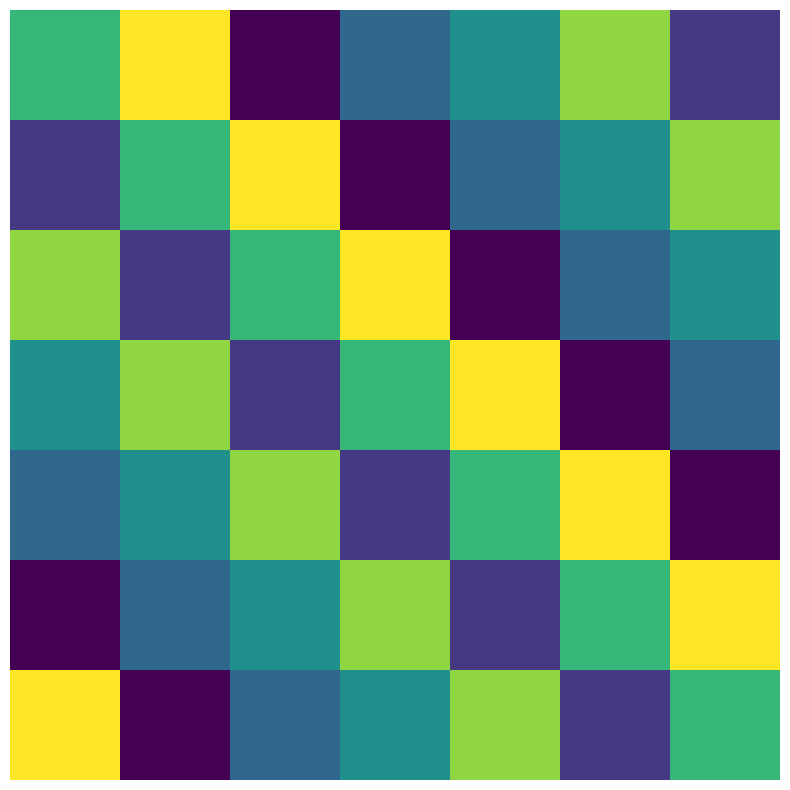

In [62]:
vis(repin, repin)

In [63]:
net

Sequential(
  (0): EMLPBlock(
    (linear): Linear(in_features=7, out_features=7, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (1): EMLPBlock(
    (linear): Linear(in_features=7, out_features=7, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (2): EMLPBlock(
    (linear): Linear(in_features=7, out_features=7, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (3): Linear(in_features=7, out_features=1, bias=True)
)

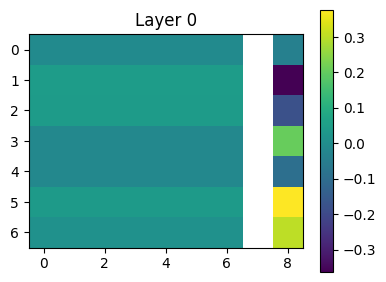

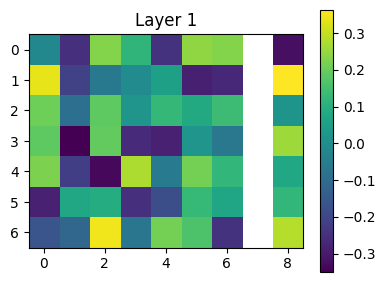

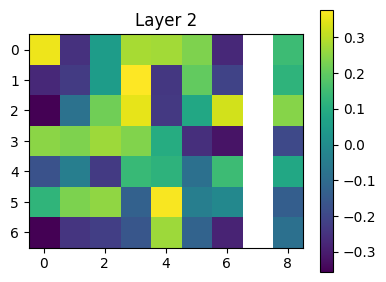

AttributeError: 'Linear' object has no attribute 'linear'

In [67]:
for layer_idx in np.arange(len(args.vanilla_layer_dims)):
    lin = net[layer_idx].linear
    w, b = lin.proj_w(lin.weight), lin.proj_b(lin.bias)

    wb_plot_pred(w, b, title = f'Layer {layer_idx}')